# ARIMA 

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import random 

from math import sqrt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
# from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

### Import Data

In [2]:
data = pd.read_csv("/Users/alexzheng/Developer/GitHub/EC331-project/data/Bitcoin_data.csv", 
                   index_col=0, 
                   parse_dates=True) # set index to datetime 

In [3]:
data.head()

,open,high,low,close
date,,,,
2018-05-15 06:00:00,8733.86,8796.68,8707.28,8740.99
2018-05-15 07:00:00,8740.99,8766.00,8721.11,8739.00
2018-05-15 08:00:00,8739.00,8750.27,8660.53,8728.49
2018-05-15 09:00:00,8728.49,8754.40,8701.35,8708.32
2018-05-15 10:00:00,8708.32,8865.00,8695.11,8795.90


In [4]:
# !pip install --upgrade numpy==1.26.4

In [5]:
# Copy the original dataset 
data_arima = data.copy()

# Apply First Differencing
data_arima['close_diff'] = data_arima['close'].diff()

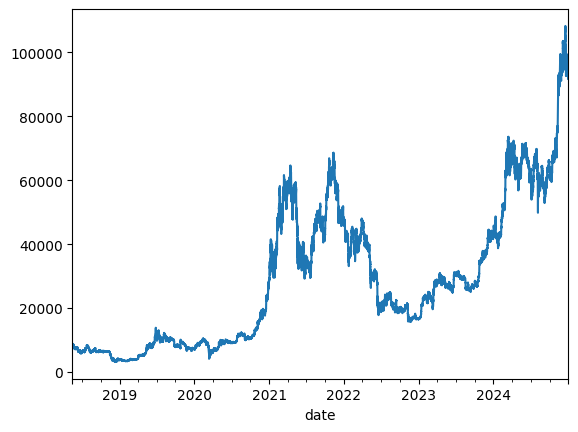

In [6]:
data_arima['close'].plot();

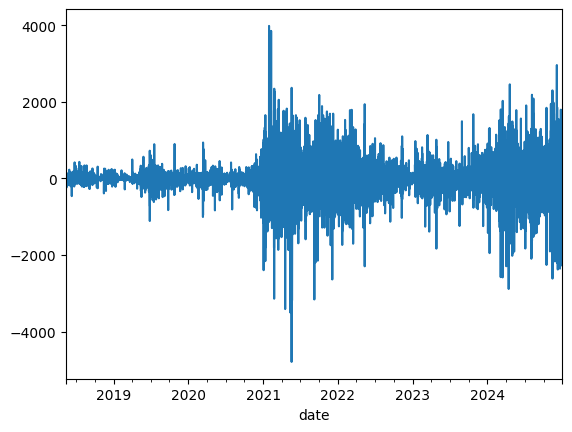

In [7]:
data_arima['close_diff'].plot();

In [8]:
# ADF Test for Stationarity
result_diff = adfuller(data_arima['close_diff'].dropna())
print(f"ADF Test Statistic: {result_diff[0]}")
print(f"p-value: {result_diff[1]}")

# If data is still non-stationary, consider second differencing
if result_diff[1] > 0.05:
    print("Data is non-stationary. Consider second differencing.")
else:
    print("Data is stationary.")

ADF Test Statistic: -30.7414294313608
p-value: 0.0
Data is stationary.


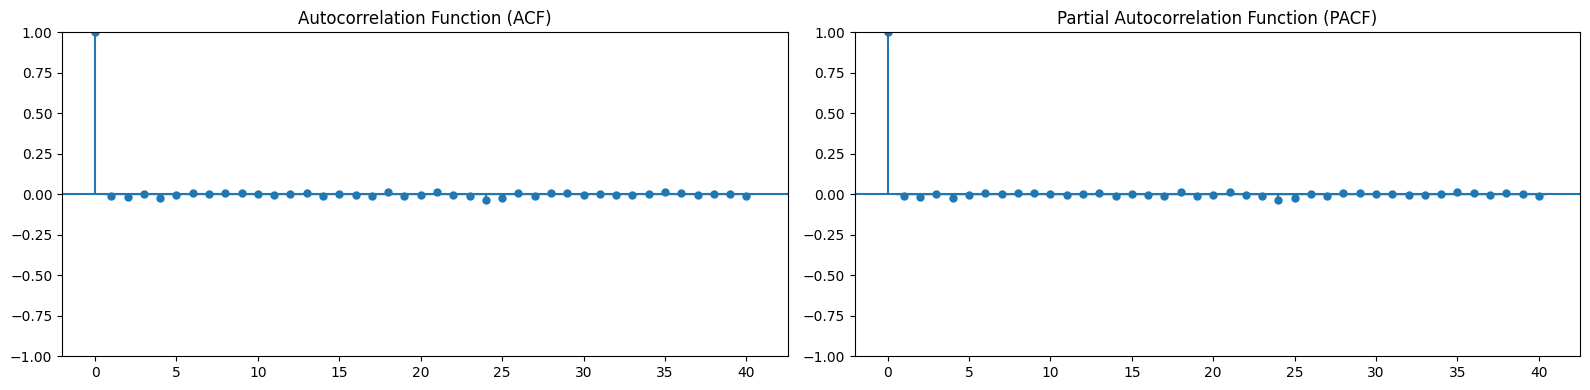

In [9]:
# Plot ACF and PACF for the differenced series
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# ACF plot
plot_acf(data_arima['close_diff'].dropna(), lags=40, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)')

# PACF plot
plot_pacf(data_arima['close_diff'].dropna(), lags=40, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.show()

In [10]:
from pmdarima import auto_arima

# Find optimal ARIMA order
stepwise_fit = auto_arima(data_arima['close'], seasonal=False, suppress_warnings=True)
order = stepwise_fit.order
print(f"Optimal ARIMA order: {order}")

Optimal ARIMA order: (4, 1, 0)


### Forecasting with ARIMA

In [11]:
# Split data into train and test
train_size = int(len(data_arima) * 0.8)
arima_train, arima_test = data_arima.iloc[:train_size], data_arima.iloc[train_size:]

# Fit ARIMA model
arima_model = ARIMA(arima_train["close"], order=(4,1,0))
arima_model_fit = arima_model.fit()
print(arima_model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  close   No. Observations:                46516
Model:                 ARIMA(4, 1, 0)   Log Likelihood             -314848.232
Date:                Mon, 03 Feb 2025   AIC                         629706.465
Time:                        01:32:56   BIC                         629750.202
Sample:                    05-15-2018   HQIC                        629720.211
                         - 09-04-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0072      0.002     -4.267      0.000      -0.011      -0.004
ar.L2         -0.0184      0.002     -9.429      0.000      -0.022      -0.015
ar.L3          0.0049      0.002      2.320      0.0

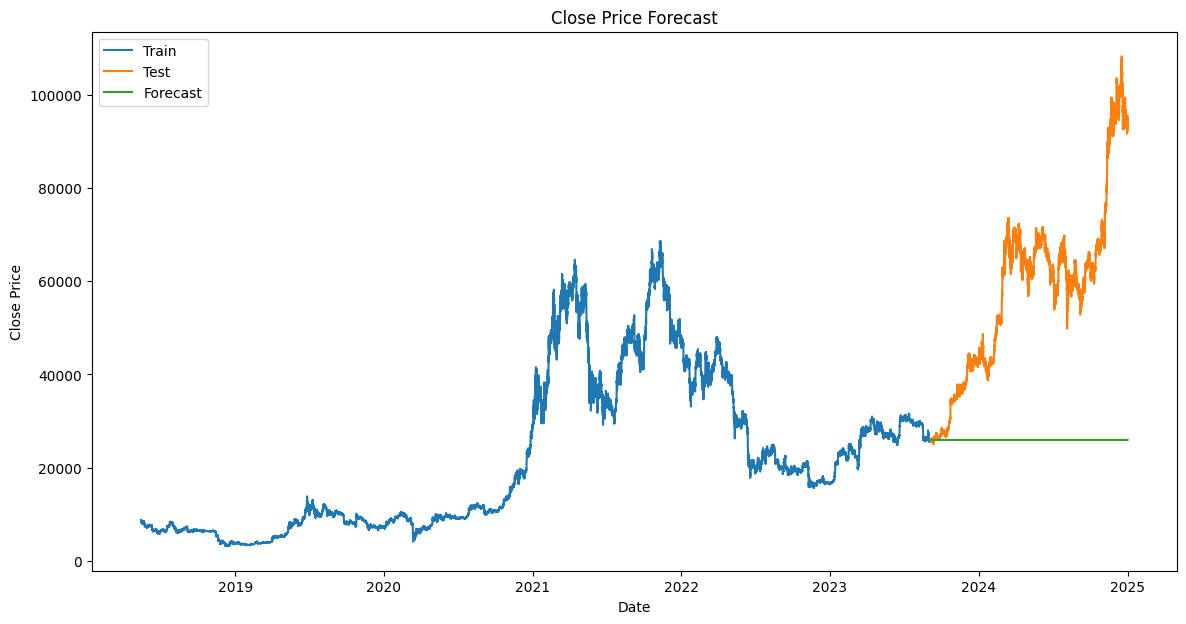

In [12]:
# Forecast
forecast = arima_model_fit.forecast(steps=len(arima_test))

# Plot the results
plt.figure(figsize=(14,7))
plt.plot(arima_train.index, arima_train["close"], label='Train')
plt.plot(arima_test.index, arima_test["close"], label='Test')
plt.plot(arima_test.index, forecast, label='Forecast')
plt.title('Close Price Forecast')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

In [13]:
# Evaluate model statistics
print(f"AIC: {arima_model_fit.aic}")
print(f"BIC: {arima_model_fit.bic}")

forecast = forecast[:len(arima_test)]
arima_test_close = arima_test["close"][:len(forecast)]

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(arima_test_close, forecast))
print(f"RMSE: {rmse:.4f}")

AIC: 629706.4646010415
BIC: 629750.2022516425
RMSE: 37342.7130


In [14]:
# # Method 2 using `auto_arima`: 
# from pmdarima import auto_arima

# # Find optimal ARIMA order
# stepwise_fit = auto_arima(data_arima['close'], seasonal=False, suppress_warnings=True)
# order = stepwise_fit.order
# print(f"Optimal ARIMA order: {order}")

# # Split data
# train_size = int(len(data_arima) * 0.8)  # 80% train, 20% test
# arima_train = data_arima.iloc[:train_size]
# arima_test = data_arima.iloc[train_size:]

# # Train ARIMA model
# arima_model = ARIMA(arima_train['close'], order=order)
# arima_model = arima_model.fit()
# print(arima_model.summary())

# # Make predictions
# arima_pred = arima_model.predict(start=len(arima_train), end=len(data_arima)-1)

# # Evaluate model performance
# arima_RMSE = sqrt(mean_squared_error(arima_test['close'], arima_pred))
# print(f"ARIMA RMSE: {arima_RMSE}")

# # Plot actual vs predicted prices
# plt.figure(figsize=(12, 6))
# arima_test['close'].plot(label="Actual Close Price", legend=True, linewidth=2)
# arima_pred.plot(label="ARIMA Predictions", linestyle="dashed", legend=True, linewidth=2)
# plt.xlabel("Date")
# plt.ylabel("Close Price")
# plt.title("ARIMA Model - Close Price Prediction")
# plt.legend()
# plt.show()